In [2]:
# Shared simulation functions (vectorized) ---


import numpy as np

n = 100  # grid dimension, shared by all spatial simulations

def grid_to_num(grid_str):
    """Convert an 'H'/'D' string array to a 1/0 integer array."""
    return (np.asarray(grid_str) == 'H').astype(int)

def grid_to_str(grid_num):
    """Convert a 1/0 integer array back to an 'H'/'D' string array."""
    return np.where(np.asarray(grid_num) == 1, 'H', 'D')

def _shift_slices(di, dj):
    """Helper: source/destination slices for shifting an array by (di, dj) with no wraparound."""
    src = [slice(None), slice(None)]
    dst = [slice(None), slice(None)]
    if di == -1:
        dst[0] = slice(1, None); src[0] = slice(None, -1)
    elif di == 1:
        dst[0] = slice(None, -1); src[0] = slice(1, None)
    if dj == -1:
        dst[1] = slice(1, None); src[1] = slice(None, -1)
    elif dj == 1:
        dst[1] = slice(None, -1); src[1] = slice(1, None)
    return tuple(src), tuple(dst)

_NEIGHBOR_SHIFTS = [(-1, 0), (1, 0), (0, -1), (0, 1)]

def calculate_payoff_grid(grid_num, I_grid, b, c):
    """Computes the payoff for every cell simultaneously (vectorized equivalent of
    calling calculate_payoff() once per cell). grid_num: 1=Hawk, 0=Dove."""
    payoff = np.zeros_like(grid_num, dtype=float)
    for di, dj in _NEIGHBOR_SHIFTS:
        src, dst = _shift_slices(di, dj)
        nb = np.full_like(grid_num, -1)
        nb[dst] = grid_num[src]
        valid = nb >= 0
        nb_is_hawk = (nb == 1)
        contrib_if_focal_hawk = np.where(nb_is_hawk, b - c - I_grid, b - I_grid)
        contrib_if_focal_dove = np.where(nb_is_hawk, 0.0, b / 2)
        contrib = np.where(grid_num == 1, contrib_if_focal_hawk, contrib_if_focal_dove)
        payoff += np.where(valid, contrib, 0.0)
    return payoff

def update_grid_num(grid_num, b, c, I_grid):
    """One synchronous update step (vectorized). Each cell compares its payoff to one
    randomly chosen neighbor's payoff and copies that neighbor's strategy if it is strictly
    higher -- identical rule to the per-cell loop version, applied to all cells at once."""
    payoff = calculate_payoff_grid(grid_num, I_grid, b, c)
    directions = np.random.randint(0, 4, size=grid_num.shape)
    new_grid = grid_num.copy()
    for d, (di, dj) in enumerate(_NEIGHBOR_SHIFTS):
        mask_dir = (directions == d)
        src, dst = _shift_slices(di, dj)
        nb_grid = np.full_like(grid_num, -1)
        nb_payoff = np.full_like(payoff, -np.inf)
        nb_grid[dst] = grid_num[src]
        nb_payoff[dst] = payoff[src]
        valid_nb = nb_grid >= 0
        adopt = mask_dir & valid_nb & (nb_payoff > payoff)
        new_grid = np.where(adopt, nb_grid, new_grid)
    return new_grid

# --- String-based wrappers, so existing cells using 'H'/'D' grids need no other changes ---

def calculate_payoff(grid, i, j, b, c, I):
    """Single-cell payoff (string-grid interface, kept for any code that still calls this
    directly). For bulk simulation, prefer update_grid(), which is fully vectorized."""
    grid_num = grid_to_num(grid)
    full_payoff = calculate_payoff_grid(grid_num, np.full(grid.shape, I), b, c)
    return full_payoff[i, j]

def update_grid(grid, b, c, I_grid):
    """Drop-in replacement for the original update_grid(): takes and returns an 'H'/'D'
    string array, identical interface to the original loop-based version, but runs the
    vectorized update internally (~100x faster)."""
    grid_num = grid_to_num(grid)
    new_num = update_grid_num(grid_num, b, c, I_grid)
    return grid_to_str(new_num)

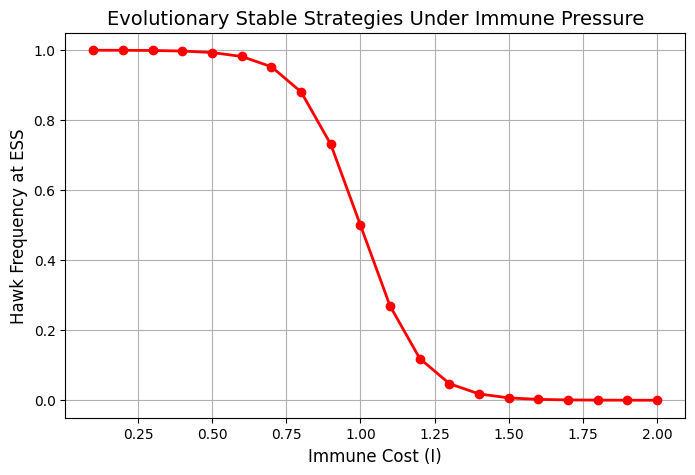

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Parameters (modify based on data)
b = 2.0   # Benefit of resource uptake (e.g., glucose)
c = 1.0   # Cost of competition (e.g., energy wasted on aggression)
I_range = np.linspace(0.1, 2.0, 20)  # Immune cost range (low to high pressure)

# Replicator equation
def replicator(xH, t, b, c, I):
    xD = 1 - xH
    fH = xH * (b - c - I) + xD * (b - I)  # Hawk fitness
    fD = xD * (b / 2)                      # Dove fitness
    phi = xH * fH + xD * fD                 # Mean fitness
    return xH * (fH - phi)

# Simulate ESS for different immune pressures
results = []
for I in I_range:
    time = np.linspace(0, 10, 100)  # Simulation time
    xH_initial = 0.5                # Initial Hawk frequency (50%)
    xH = odeint(replicator, xH_initial, time, args=(b, c, I))[-1]  # Equilibrium
    results.append(xH[0])

# Plot ESS vs. Immune cost
plt.figure(figsize=(8, 5))
plt.plot(I_range, results, 'o-', color='red', linewidth=2)
plt.xlabel('Immune Cost (I)', fontsize=12)
plt.ylabel('Hawk Frequency at ESS', fontsize=12)
plt.title('Evolutionary Stable Strategies Under Immune Pressure', fontsize=14)
plt.grid(True)
plt.show()

In [19]:
#Pearson r test on the above plot (can be used again for other plots)

from scipy.stats import pearsonr

# Calculate Pearson r and p-value
correlation, p_value = pearsonr(I_range, results)

print(f"Pearson r correlation coefficient: {correlation:.4f}")
print(f"P-value: {p_value:.4f}")

Pearson r correlation coefficient: -0.9358
P-value: 0.0000


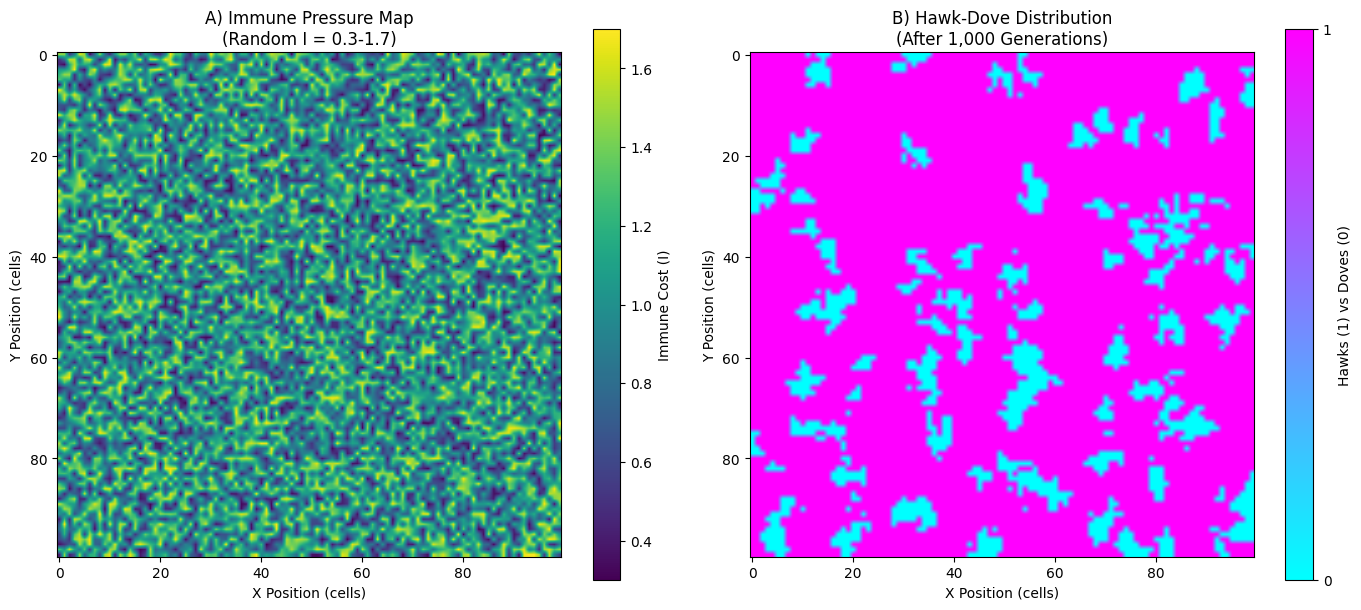

Pearson correlation between Hawk presence and Immune cost: r=-0.253, p=2.06e-145


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Parameters
n = 100  # Grid size
b, c = 2.0, 1.0  # Payoff parameters (b > c)
I_min, I_max = 0.3, 1.7  # Immune pressure range
iterations = 1000  # High # of iterations for equilibrium

# Initialize grid and immune pressure
grid = np.random.choice(['H', 'D'], size=(n, n))
I_grid = np.random.uniform(I_min, I_max, size=(n, n))  # Spatially varying I

# Run simulation
for _ in range(iterations):
    grid = update_grid(grid, b, c, I_grid)

# Create 2-panel figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Panel A: Immune Pressure Map
im1 = ax1.imshow(I_grid, cmap='viridis', interpolation='bilinear')
ax1.set_title('A) Immune Pressure Map\n(Random I = 0.3-1.7)', fontsize=12)
ax1.set_xlabel('X Position (cells)')
ax1.set_ylabel('Y Position (cells)')
cbar1 = plt.colorbar(im1, ax=ax1)
cbar1.set_label('Immune Cost (I)')

# Panel B: Hawk-Dove Distribution
hawk_dove_visual = np.array([[1 if cell == 'H' else 0 for cell in row] for row in grid])
im2 = ax2.imshow(hawk_dove_visual, cmap='cool', interpolation='bilinear')
ax2.set_title('B) Hawk-Dove Distribution\n(After 1,000 Generations)', fontsize=12)
ax2.set_xlabel('X Position (cells)')
ax2.set_ylabel('Y Position (cells)')
cbar2 = plt.colorbar(im2, ax=ax2, ticks=[0, 1])
cbar2.set_label('Hawks (1) vs Doves (0)')

plt.tight_layout()
plt.show()

# Calculate correlation for results section

hawk_dove_array = hawk_dove_visual.flatten()
I_array = I_grid.flatten()
correlation, p_value = pearsonr(hawk_dove_array, I_array)
print(f"Pearson correlation between Hawk presence and Immune cost: r={correlation:.3f}, p={p_value:.4g}")

Replicate 5/100 done.
Replicate 10/100 done.
Replicate 15/100 done.
Replicate 20/100 done.
Replicate 25/100 done.
Replicate 30/100 done.
Replicate 35/100 done.
Replicate 40/100 done.
Replicate 45/100 done.
Replicate 50/100 done.
Replicate 55/100 done.
Replicate 60/100 done.
Replicate 65/100 done.
Replicate 70/100 done.
Replicate 75/100 done.
Replicate 80/100 done.
Replicate 85/100 done.
Replicate 90/100 done.
Replicate 95/100 done.
Replicate 100/100 done.


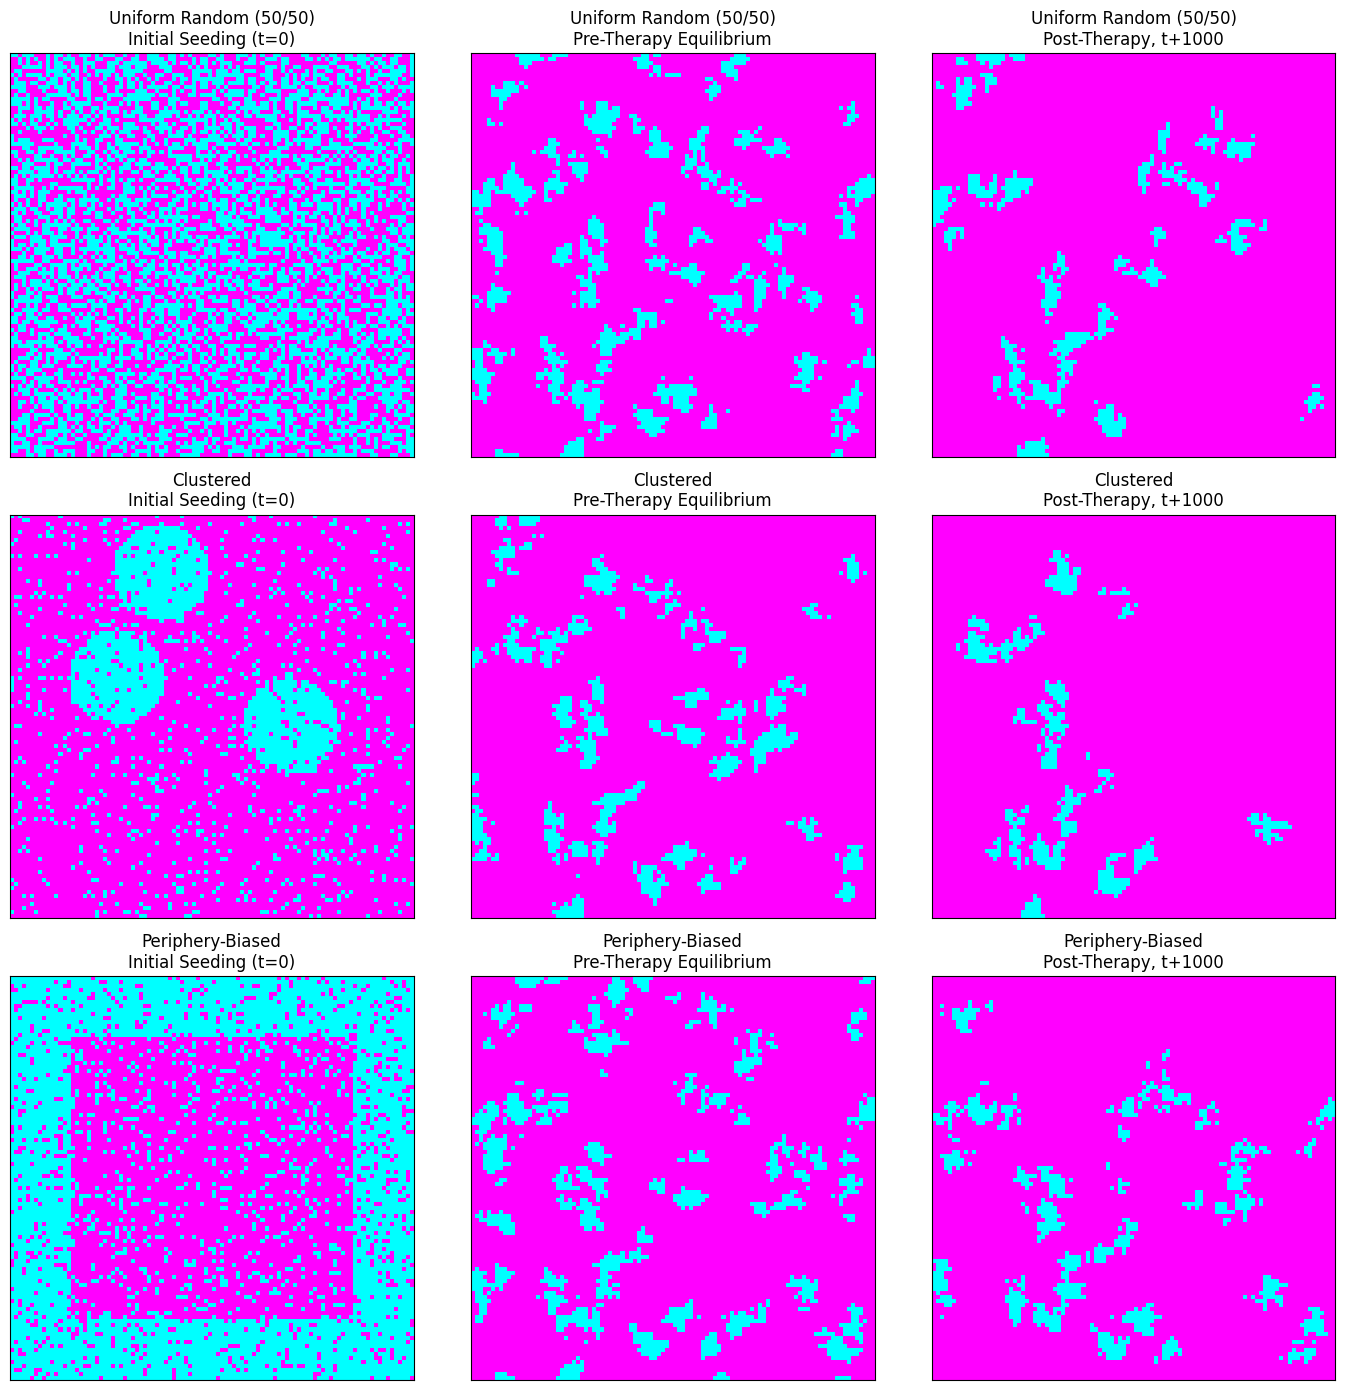


Seeding condition comparison, averaged over 100 replicates (fresh immune-pressure landscape per replicate):
  Uniform Random (50/50): pre-therapy=1408±160, post-therapy=813±169, resurgence=0.576x ± 0.093
  Clustered: pre-therapy=1150±167, post-therapy=734±175, resurgence=0.637x ± 0.113
  Periphery-Biased: pre-therapy=1512±159, post-therapy=815±197, resurgence=0.536x ± 0.103

One-way ANOVA across all 3 conditions: F=23.951, p=0.0000
Uniform vs Clustered:        t=-4.140, p=0.0001
Uniform vs Periphery-Biased: t=2.873, p=0.0045
Clustered vs Periphery-Biased: t=6.564, p=0.0000


In [4]:
# Seeding-condition comparison (uniform vs. clustered vs. periphery-biased) ---


import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

n = 100
b, c = 2.0, 1.0
I_min, I_max = 0.3, 1.7
iterations = 1000
post_therapy_iterations = 1000
n_replicates = 100

def seed_uniform(n, p_dove=0.5):
    return np.random.choice(['H', 'D'], size=(n, n), p=[1 - p_dove, p_dove])

def seed_clustered(n, n_clusters=3, radius=None, p_dove_in_cluster=0.9, p_dove_background=0.1,
                    min_center_distance=None, max_attempts=200):
    """Doves concentrated in compact circular clusters (models a pre-existing resistant subclone).
    Cluster centers are placed with a minimum separation so clusters appear as genuinely distinct
    pockets rather than overlapping/merging into one larger blob."""
    if radius is None:
        radius = max(2, n // 8)
    if min_center_distance is None:
        min_center_distance = 2.2 * radius
    grid = np.random.choice(['H', 'D'], size=(n, n), p=[1 - p_dove_background, p_dove_background])

    centers = []
    for _ in range(n_clusters):
        for attempt in range(max_attempts):
            candidate = np.random.randint(radius, max(radius + 1, n - radius), size=2)
            if all(np.linalg.norm(candidate - np.array(c)) >= min_center_distance for c in centers):
                centers.append(candidate)
                break
        else:
            centers.append(np.random.randint(radius, max(radius + 1, n - radius), size=2))

    yy, xx = np.mgrid[0:n, 0:n]
    for cy, cx in centers:
        mask = (yy - cy) ** 2 + (xx - cx) ** 2 <= radius ** 2
        rand_mask = np.random.rand(n, n) < p_dove_in_cluster
        grid[mask & rand_mask] = 'D'
    return grid

def seed_periphery(n, p_dove_edge=0.85, p_dove_core=0.15, edge_width=15):
    """Doves seeded preferentially at the tumor edge ."""
    grid = np.empty((n, n), dtype='<U1')
    yy, xx = np.mgrid[0:n, 0:n]
    dist_to_edge = np.minimum.reduce([yy, n - 1 - yy, xx, n - 1 - xx])
    is_edge = dist_to_edge < edge_width
    rand_grid = np.random.rand(n, n)
    grid[is_edge] = np.where(rand_grid[is_edge] < p_dove_edge, 'D', 'H')
    grid[~is_edge] = np.where(rand_grid[~is_edge] < p_dove_core, 'D', 'H')
    return grid

seed_functions = {
    'Uniform Random (50/50)': seed_uniform,
    'Clustered': seed_clustered,
    'Periphery-Biased': seed_periphery,
}

all_results = {label: {'pre': [], 'post': [], 'resurgence': []} for label in seed_functions}
last_rep_grids = {}

for rep in range(n_replicates):
    I_grid_seed = np.random.uniform(I_min, I_max, size=(n, n))  # fresh terrain each replicate

    for label, seed_fn in seed_functions.items():
        initial_grid_s = seed_fn(n)
        grid_s = initial_grid_s.copy()

        for _ in range(iterations):
            grid_s = update_grid(grid_s, b, c, I_grid_seed)
        pre_doves = int(np.sum(grid_s == 'D'))

        therapy_grid_s = np.where(np.random.rand(n, n) < 0.1, grid_s, 'H')
        for _ in range(post_therapy_iterations):
            therapy_grid_s = update_grid(therapy_grid_s, b, c, I_grid_seed)
        post_doves = int(np.sum(therapy_grid_s == 'D'))

        resurgence = post_doves / pre_doves if pre_doves else float('nan')
        all_results[label]['pre'].append(pre_doves)
        all_results[label]['post'].append(post_doves)
        all_results[label]['resurgence'].append(resurgence)

        if rep == n_replicates - 1:
            last_rep_grids[label] = (initial_grid_s.copy(), grid_s.copy(), therapy_grid_s.copy())

    if (rep + 1) % 5 == 0:
        print(f"Replicate {rep+1}/{n_replicates} done.")

# --- Figure: representative panels from the final replicate ---
fig, axes = plt.subplots(3, 3, figsize=(14, 14))
for row, label in enumerate(seed_functions):
    initial_grid, pre_grid, post_grid = last_rep_grids[label]
    axes[row, 0].imshow([[1 if c == 'H' else 0 for c in r] for r in initial_grid], cmap='cool')
    axes[row, 0].set_title(f'{label}\nInitial Seeding (t=0)')
    axes[row, 1].imshow([[1 if c == 'H' else 0 for c in r] for r in pre_grid], cmap='cool')
    axes[row, 1].set_title(f'{label}\nPre-Therapy Equilibrium')
    axes[row, 2].imshow([[1 if c == 'H' else 0 for c in r] for r in post_grid], cmap='cool')
    axes[row, 2].set_title(f'{label}\nPost-Therapy, t+{post_therapy_iterations}')
for ax_row in axes:
    for ax in ax_row:
        ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

# --- Summary statistics ---
print(f"\nSeeding condition comparison, averaged over {n_replicates} replicates "
      f"(fresh immune-pressure landscape per replicate):")
resurgence_by_label = {}
for label, r in all_results.items():
    pre_mean, pre_sd = np.mean(r['pre']), np.std(r['pre'])
    post_mean, post_sd = np.mean(r['post']), np.std(r['post'])
    res_mean, res_sd = np.mean(r['resurgence']), np.std(r['resurgence'])
    resurgence_by_label[label] = np.array(r['resurgence'])
    print(f"  {label}: pre-therapy={pre_mean:.0f}±{pre_sd:.0f}, "
          f"post-therapy={post_mean:.0f}±{post_sd:.0f}, "
          f"resurgence={res_mean:.3f}x ± {res_sd:.3f}")

# --- Statistical tests ---
uniform_r = resurgence_by_label['Uniform Random (50/50)']
clustered_r = resurgence_by_label['Clustered']
periphery_r = resurgence_by_label['Periphery-Biased']

f_stat, p_anova = stats.f_oneway(uniform_r, clustered_r, periphery_r)
print(f"\nOne-way ANOVA across all 3 conditions: F={f_stat:.3f}, p={p_anova:.4f}")

t_uc, p_uc = stats.ttest_ind(uniform_r, clustered_r)
t_up, p_up = stats.ttest_ind(uniform_r, periphery_r)
t_cp, p_cp = stats.ttest_ind(clustered_r, periphery_r)
print(f"Uniform vs Clustered:        t={t_uc:.3f}, p={p_uc:.4f}")
print(f"Uniform vs Periphery-Biased: t={t_up:.3f}, p={p_up:.4f}")
print(f"Clustered vs Periphery-Biased: t={t_cp:.3f}, p={p_cp:.4f}")


Converged at iteration 67


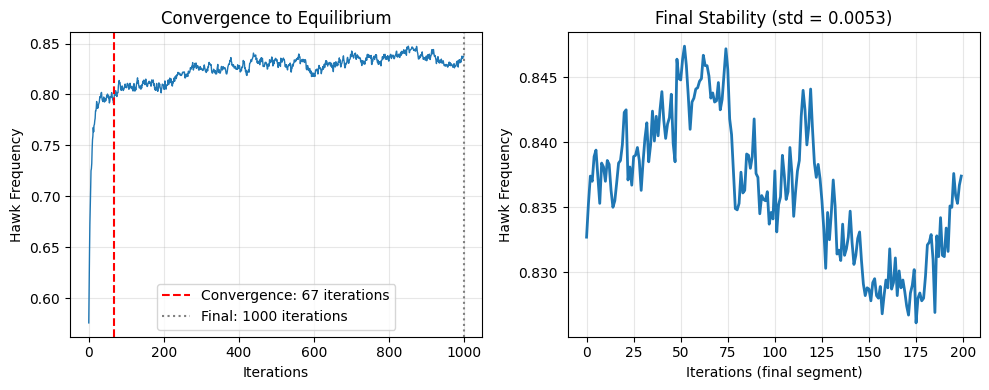


Convergence Analysis:
Final Hawk frequency: 0.833 ± 0.004
Convergence point: 67
Total iterations: 1000


In [22]:
# Figure 5: Convergence analysis ---
# Uses calculate_payoff/update_grid from the shared functions cell at the top of the notebook.

import matplotlib.pyplot as plt

# Parameters
b, c = 2.0, 1.0
I_min, I_max = 0.3, 1.7
iterations = 1000

# Initialize
grid = np.random.choice(['H', 'D'], size=(n, n))
I_grid = np.random.uniform(I_min, I_max, size=(n, n))

# Run simulation WITH convergence tracking
hawk_frequencies = []
convergence_point = None

for iteration in range(iterations):
    grid = update_grid(grid, b, c, I_grid)

    # Track Hawk frequency
    hawk_freq = np.mean([[1 if cell == 'H' else 0 for cell in row] for row in grid])
    hawk_frequencies.append(hawk_freq)

    # Check for convergence (stable for last 50 iterations)
    if iteration > 50:
        recent_std = np.std(hawk_frequencies[-50:])
        if recent_std < 0.005:  # 0.5% stability threshold
            if convergence_point is None:
                convergence_point = iteration
                print(f"Converged at iteration {convergence_point}")

# Create convergence figure
plt.figure(figsize=(10, 4))

# Plot convergence
plt.subplot(1, 2, 1)
plt.plot(hawk_frequencies, linewidth=1)
if convergence_point:
    plt.axvline(x=convergence_point, color='red', linestyle='--',
                label=f'Convergence: {convergence_point} iterations')
plt.axvline(x=iterations, color='gray', linestyle=':',
            label=f'Final: {iterations} iterations')
plt.xlabel('Iterations')
plt.ylabel('Hawk Frequency')
plt.title('Convergence to Equilibrium')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot final stability (last 200 iterations)
plt.subplot(1, 2, 2)
final_range = hawk_frequencies[-200:] if len(hawk_frequencies) > 200 else hawk_frequencies
plt.plot(final_range, linewidth=2)
plt.xlabel('Iterations (final segment)')
plt.ylabel('Hawk Frequency')
plt.title(f'Final Stability (std = {np.std(final_range):.4f})')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print convergence statistics
final_std = np.std(hawk_frequencies[-100:])
mean_freq = np.mean(hawk_frequencies[-100:])
print(f"\nConvergence Analysis:")
print(f"Final Hawk frequency: {mean_freq:.3f} ± {final_std:.3f}")
print(f"Convergence point: {convergence_point if convergence_point else 'Not reached (stable by end)'}")
print(f"Total iterations: {iterations}")

Cells per bin (mean=500, min=456, max=540)


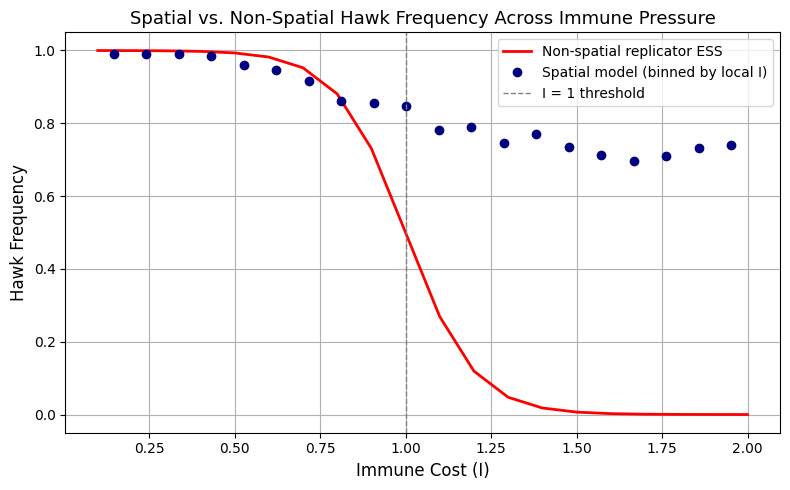

In [23]:
# Spatial vs. non-spatial comparison

import numpy as np
import matplotlib.pyplot as plt

# Use a wider I range so bins span the same domain as the non-spatial I_range (0.1-2.0)
n = 100
b, c = 2.0, 1.0
I_min_wide, I_max_wide = 0.1, 2.0
iterations = 1000
n_bins = 20

# Initialize grid and a spatially varying I_grid spanning the full non-spatial range
grid_cmp = np.random.choice(['H', 'D'], size=(n, n))
I_grid_cmp = np.random.uniform(I_min_wide, I_max_wide, size=(n, n))

# Run to equilibrium (reuses update_grid/calculate_payoff from Cell 2)
for _ in range(iterations):
    grid_cmp = update_grid(grid_cmp, b, c, I_grid_cmp)

# Bin cells by local I and compute mean Hawk frequency per bin
I_flat = I_grid_cmp.flatten()
hawk_flat = (grid_cmp.flatten() == 'H').astype(float)

bin_edges = np.linspace(I_min_wide, I_max_wide, n_bins + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
spatial_hawk_freq = np.full(n_bins, np.nan)
bin_counts = np.zeros(n_bins, dtype=int)

for k in range(n_bins):
    in_bin = (I_flat >= bin_edges[k]) & (I_flat < bin_edges[k + 1] if k < n_bins - 1 else I_flat <= bin_edges[k + 1])
    bin_counts[k] = in_bin.sum()
    if in_bin.sum() > 0:
        spatial_hawk_freq[k] = hawk_flat[in_bin].mean()

print(f"Cells per bin (mean={bin_counts.mean():.0f}, min={bin_counts.min()}, max={bin_counts.max()})")

# --- Non-spatial replicator curve
from scipy.integrate import odeint

def replicator(xH, t, b, c, I):
    xD = 1 - xH
    fH = xH * (b - c - I) + xD * (b - I)
    fD = xD * (b / 2)
    phi = xH * fH + xD * fD
    return xH * (fH - phi)

I_range_nonspatial = np.linspace(0.1, 2.0, 20)
nonspatial_results = []
for I in I_range_nonspatial:
    time = np.linspace(0, 10, 100)
    xH = odeint(replicator, 0.5, time, args=(b, c, I))[-1]
    nonspatial_results.append(xH[0])

# --- Overlay plot ---
plt.figure(figsize=(8, 5))
plt.plot(I_range_nonspatial, nonspatial_results, '-', color='red', linewidth=2,
         label='Non-spatial replicator ESS')
plt.plot(bin_centers, spatial_hawk_freq, 'o', color='navy', markersize=6,
         label='Spatial model (binned by local I)')
plt.axvline(x=1.0, color='gray', linestyle='--', linewidth=1, label='I = 1 threshold')
plt.xlabel('Immune Cost (I)', fontsize=12)
plt.ylabel('Hawk Frequency', fontsize=12)
plt.title('Spatial vs. Non-Spatial Hawk Frequency Across Immune Pressure', fontsize=13)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [24]:
# Figure 3B significance test: spatial vs. non-spatial Hawk frequency ---


import numpy as np
from scipy.integrate import odeint
from scipy import stats

n = 100
b, c = 2.0, 1.0
iterations = 1000
n_bins = 20
I_min_wide, I_max_wide = 0.1, 2.0
n_replicates = 30

bin_edges = np.linspace(I_min_wide, I_max_wide, n_bins + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# --- Non-spatial replicator curve (ground truth to compare against) ---
def replicator(xH, t, b, c, I):
    xD = 1 - xH
    fH = xH * (b - c - I) + xD * (b - I)
    fD = xD * (b / 2)
    phi = xH * fH + xD * fD
    return xH * (fH - phi)

nonspatial_at_bin = []
for I in bin_centers:
    time = np.linspace(0, 10, 100)
    xH = odeint(replicator, 0.5, time, args=(b, c, I))[-1][0]
    nonspatial_at_bin.append(xH)
nonspatial_at_bin = np.array(nonspatial_at_bin)

# --- Run the spatial model across multiple replicates ---
spatial_freq_by_replicate = np.full((n_replicates, n_bins), np.nan)

for rep in range(n_replicates):
    grid = np.random.choice(['H', 'D'], size=(n, n))
    I_grid = np.random.uniform(I_min_wide, I_max_wide, size=(n, n))
    for _ in range(iterations):
        grid = update_grid(grid, b, c, I_grid)

    I_flat = I_grid.flatten()
    hawk_flat = (grid.flatten() == 'H').astype(float)
    for k in range(n_bins):
        in_bin = (I_flat >= bin_edges[k]) & (I_flat < bin_edges[k+1] if k < n_bins-1 else I_flat <= bin_edges[k+1])
        if in_bin.sum() > 0:
            spatial_freq_by_replicate[rep, k] = hawk_flat[in_bin].mean()

    if (rep + 1) % 5 == 0:
        print(f"Replicate {rep+1}/{n_replicates} done.")

spatial_mean = np.nanmean(spatial_freq_by_replicate, axis=0)
spatial_sd = np.nanstd(spatial_freq_by_replicate, axis=0)

# --- Statistical test: for each bin, one-sample t-test of spatial replicates against the
#     non-spatial prediction at that I value ---
print(f"\nPer-bin comparison (spatial model, n={n_replicates} replicates, vs. non-spatial prediction):")
print(f"{'I (bin center)':>15} {'Non-spatial':>12} {'Spatial mean±SD':>18} {'t':>8} {'p':>10}")
high_I_pvals = []
for k in range(n_bins):
    vals = spatial_freq_by_replicate[:, k]
    vals = vals[~np.isnan(vals)]
    if len(vals) < 2:
        continue
    t_stat, p_val = stats.ttest_1samp(vals, nonspatial_at_bin[k])
    print(f"{bin_centers[k]:>15.3f} {nonspatial_at_bin[k]:>12.3f} "
          f"{spatial_mean[k]:>10.3f}±{spatial_sd[k]:<6.3f} {t_stat:>8.2f} {p_val:>10.4f}")
    if bin_centers[k] > 1.0:
        high_I_pvals.append(p_val)

# Summary for the high-I region specifically (where the plateau/divergence is claimed)
print(f"\nHigh-I region (I>1) summary:")
print(f"  Mean spatial Hawk frequency: {np.nanmean(spatial_mean[bin_centers > 1.0]):.3f}")
print(f"  Mean non-spatial prediction: {np.nanmean(nonspatial_at_bin[bin_centers > 1.0]):.3f}")
print(f"  All {len(high_I_pvals)} per-bin comparisons in I>1 region significant at p<0.05: "
      f"{all(p < 0.05 for p in high_I_pvals)}")
print(f"  Bonferroni-corrected threshold for {len(high_I_pvals)} comparisons: "
      f"{0.05/len(high_I_pvals):.5f}")
print(f"  All significant after Bonferroni correction: "
      f"{all(p < 0.05/len(high_I_pvals) for p in high_I_pvals)}")

Replicate 5/30 done.
Replicate 10/30 done.
Replicate 15/30 done.
Replicate 20/30 done.
Replicate 25/30 done.
Replicate 30/30 done.

Per-bin comparison (spatial model, n=30 replicates, vs. non-spatial prediction):
 I (bin center)  Non-spatial    Spatial mean±SD        t          p
          0.148        1.000      0.987±0.006    -11.23     0.0000
          0.243        0.999      0.986±0.005    -14.14     0.0000
          0.338        0.999      0.985±0.006    -13.43     0.0000
          0.432        0.997      0.984±0.005    -13.38     0.0000
          0.527        0.991      0.943±0.009    -28.25     0.0000
          0.623        0.978      0.926±0.012    -22.50     0.0000
          0.718        0.944      0.910±0.014    -12.69     0.0000
          0.812        0.867      0.844±0.019     -6.39     0.0000
          0.907        0.716      0.840±0.028     24.24     0.0000
          1.002        0.494      0.790±0.023     69.90     0.0000
          1.098        0.274      0.747±0.024    

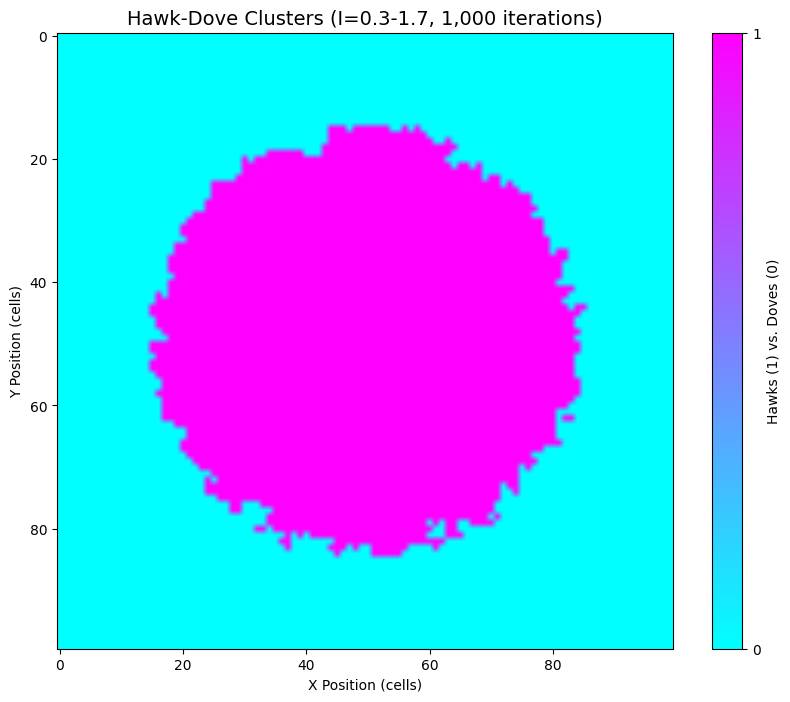

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
n = 100  # Large grid
b, c = 2.0, 1.0  # Payoff parameters (b > c)
I_min, I_max = 0.3, 1.7  # Immune pressure range (clinical)
iterations = 1000  # iterations for equilibrium

# Initialize grid and immune pressure
grid = np.random.choice(['H', 'D'], size=(n, n))
x, y = np.meshgrid(np.linspace(-1, 1, n), np.linspace(-1, 1, n))
I_grid = 0.5 + (1.0 * (x**2 + y**2))  # Center: I=0.5, Edges: I=1.5
I_grid = np.clip(I_grid, 0.5, 1.5)  # Ensure I stays in bounds


# Run simulation
for _ in range(iterations):
    grid = update_grid(grid, b, c, I_grid)

# Visualization
plt.figure(figsize=(10, 8))
plt.imshow([[1 if cell == 'H' else 0 for cell in row] for row in grid],
           cmap='cool', interpolation='bilinear')  # Smooth edges
plt.colorbar(label='Hawks (1) vs. Doves (0)', ticks=[0, 1])
plt.title('Hawk-Dove Clusters (I=0.3-1.7, 1,000 iterations)', fontsize=14)
plt.xlabel('X Position (cells)' )  # units if possible
plt.ylabel('Y Position (cells)')
plt.show()

In [26]:
from scipy.stats import pearsonr
import numpy as np

# Convert the grid of 'H' and 'D' to numerical values (1 for Hawk, 0 for Dove)
hawk_dove_array = (grid == 'H').flatten()
I_array = I_grid.flatten()

# Calculate Pearson r and p-value
correlation, p_value = pearsonr(hawk_dove_array, I_array)

print(f"Pearson r correlation coefficient: {correlation:.4f}")
print(f"P-value: {p_value:.4f}")

Pearson r correlation coefficient: -0.8688
P-value: 0.0000


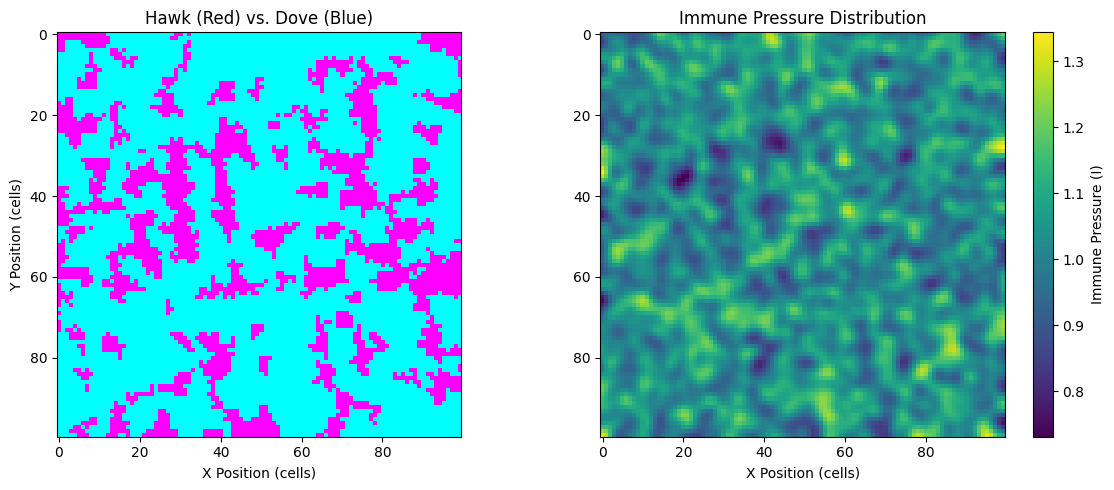

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# Generate I_grid and simulate clusters (same as before)
n = 100
b, c = 2.0, 1.0
I_min, I_max = 0.3, 1.7
iterations = 1000
I_grid = np.random.uniform(0.3, 1.7, size=(n, n))
hotspots = np.random.rand(n, n) > 0.95
I_grid[hotspots] += 0.7
I_grid = gaussian_filter(I_grid, sigma=1.5)
I_grid = np.clip(I_grid, 0.3, 1.7)

# Initialize grid
grid = np.random.choice(['H', 'D'], size=(n, n))

# Run simulation
for _ in range(iterations):
    grid = update_grid(grid, b, c, I_grid)

# Create figure
plt.figure(figsize=(12, 5))

# Plot 1: Hawk-Dove clusters
plt.subplot(121)
plt.imshow([[1 if cell == 'H' else 0 for cell in row] for row in grid],
           cmap='cool', interpolation='nearest')
plt.title('Hawk (Red) vs. Dove (Blue)')
plt.xlabel('X Position (cells)')
plt.ylabel('Y Position (cells)')

# Plot 2: Immune pressure heatmap
plt.subplot(122)
heatmap = plt.imshow(I_grid, cmap='viridis', interpolation='nearest')
plt.colorbar(heatmap, label='Immune Pressure (I)')
plt.title('Immune Pressure Distribution')
plt.xlabel('X Position (cells)')

plt.tight_layout()
plt.show()

In [5]:
from scipy.stats import pearsonr
import numpy as np

# Convert the grid of 'H' and 'D' to numerical values (1 for Hawk, 0 for Dove)
hawk_dove_array = (grid == 'H').flatten()
I_array = I_grid.flatten()

# Calculate Pearson r and p-value
correlation, p_value = pearsonr(hawk_dove_array, I_array)

print(f"Pearson r correlation coefficient: {correlation:.4f}")
print(f"P-value: {p_value:.4f}")

Pearson r correlation coefficient: -0.6105
P-value: 0.0000


In [6]:
#count dove clusters (can be used again for other charts as well)
from skimage.measure import label
dove_clusters = label(grid == 'D')
print(f"Number of Dove clusters: {dove_clusters.max()}")

Number of Dove clusters: 3


In [7]:
# Monte Carlo test: are Doves preferentially located near immune hotspots? ---


import numpy as np
from scipy.ndimage import distance_transform_edt

# Distance from every grid cell to the nearest hotspot pixel
# (hotspots is the boolean array already defined in the immune hotspot cell: np.random.rand(n,n) > 0.95)
dist_to_hotspot = distance_transform_edt(~hotspots)

# Observed: mean distance-to-nearest-hotspot for actual Dove cells
dove_mask = (grid == 'D')
observed_mean_dist = dist_to_hotspot[dove_mask].mean()

# Null distribution: reshuffle Hawk/Dove labels across the grid (preserving the same
# total number of Doves) and recompute mean distance-to-hotspot, many times
n_permutations = 1000
n_dove = dove_mask.sum()
flat_size = grid.size
null_means = np.empty(n_permutations)

rng = np.random.default_rng(0)
dist_flat = dist_to_hotspot.flatten()

for p in range(n_permutations):
    shuffled_idx = rng.choice(flat_size, size=n_dove, replace=False)
    null_means[p] = dist_flat[shuffled_idx].mean()

# Monte Carlo p-value: fraction of random arrangements at least as close to hotspots as observed
p_value = np.mean(null_means <= observed_mean_dist)
fold_closer = null_means.mean() / observed_mean_dist

print(f"Observed mean Dove-to-hotspot distance: {observed_mean_dist:.3f} cells")
print(f"Mean random-arrangement distance: {null_means.mean():.3f} cells (SD={null_means.std():.3f})")
print(f"Doves are {fold_closer:.2f}x closer to hotspots than random expectation")
print(f"Monte Carlo p-value: {p_value:.4f} (n={n_permutations} permutations)")

Observed mean Dove-to-hotspot distance: 2.197 cells
Mean random-arrangement distance: 2.330 cells (SD=0.008)
Doves are 1.06x closer to hotspots than random expectation
Monte Carlo p-value: 0.0000 (n=1000 permutations)


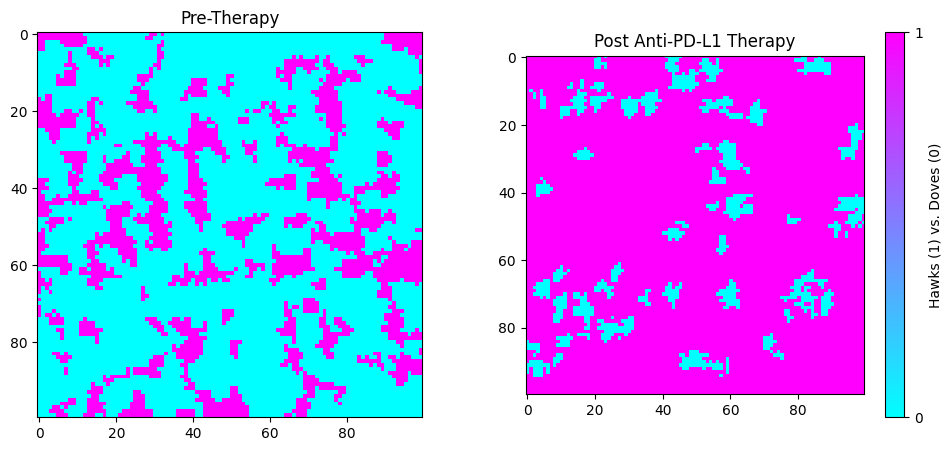

Doves pre-therapy: 7354, post-therapy: 1088


In [8]:
# Initialize post-therapy grid (remove 90% of Doves)
therapy_grid = np.where(np.random.rand(n, n) < 0.1, grid, 'H')  # 10% Doves survive

# Simulate recovery for x iterations
post_therapy_iterations = 10
for _ in range(post_therapy_iterations):
    therapy_grid = update_grid(therapy_grid, b, c, I_grid)

# Plot therapy response
plt.figure(figsize=(12, 5))
plt.subplot(121)
plt.imshow([[1 if cell == 'H' else 0 for cell in row] for row in grid], cmap='cool')
plt.title('Pre-Therapy')
plt.subplot(122)
plt.imshow([[1 if cell == 'H' else 0 for cell in row] for row in therapy_grid], cmap='cool')
plt.title('Post Anti-PD-L1 Therapy')
plt.colorbar(label='Hawks (1) vs. Doves (0)', ticks=[0, 1], ax=plt.gca())
plt.show()

# Quantify changes
pre_therapy_doves = np.sum(grid == 'D')
post_therapy_doves = np.sum(therapy_grid == 'D')
print(f"Doves pre-therapy: {pre_therapy_doves}, post-therapy: {post_therapy_doves}")

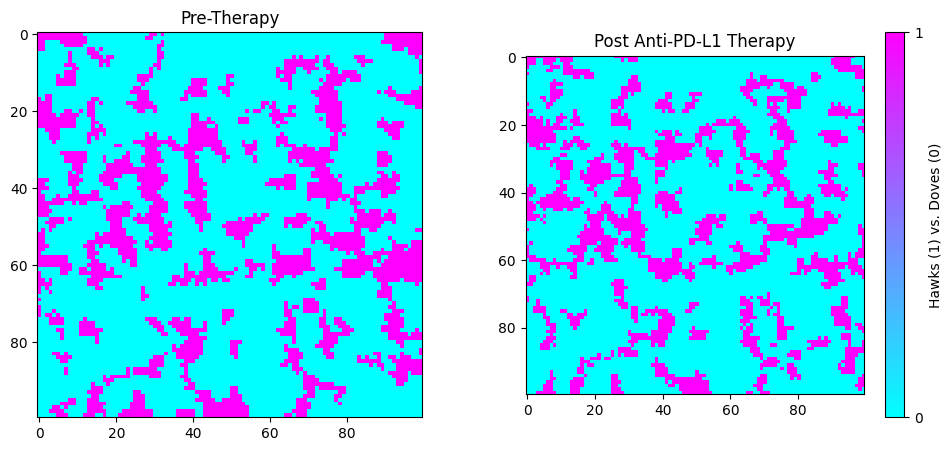

Doves pre-therapy: 7354, post-therapy: 7464


In [9]:
# Initialize post-therapy grid (remove 90% of Doves)
therapy_grid = np.where(np.random.rand(n, n) < 0.1, grid, 'H')  # 10% Doves survive

# Simulate recovery for x iterations
post_therapy_iterations = 1000
for _ in range(post_therapy_iterations):
    therapy_grid = update_grid(therapy_grid, b, c, I_grid)

# Plot therapy response
plt.figure(figsize=(12, 5))
plt.subplot(121)
plt.imshow([[1 if cell == 'H' else 0 for cell in row] for row in grid], cmap='cool')
plt.title('Pre-Therapy')
plt.subplot(122)
plt.imshow([[1 if cell == 'H' else 0 for cell in row] for row in therapy_grid], cmap='cool')
plt.title('Post Anti-PD-L1 Therapy')
plt.colorbar(label='Hawks (1) vs. Doves (0)', ticks=[0, 1], ax=plt.gca())
plt.show()

# Quantify changes
pre_therapy_doves = np.sum(grid == 'D')
post_therapy_doves = np.sum(therapy_grid == 'D')
print(f"Doves pre-therapy: {pre_therapy_doves}, post-therapy: {post_therapy_doves}")

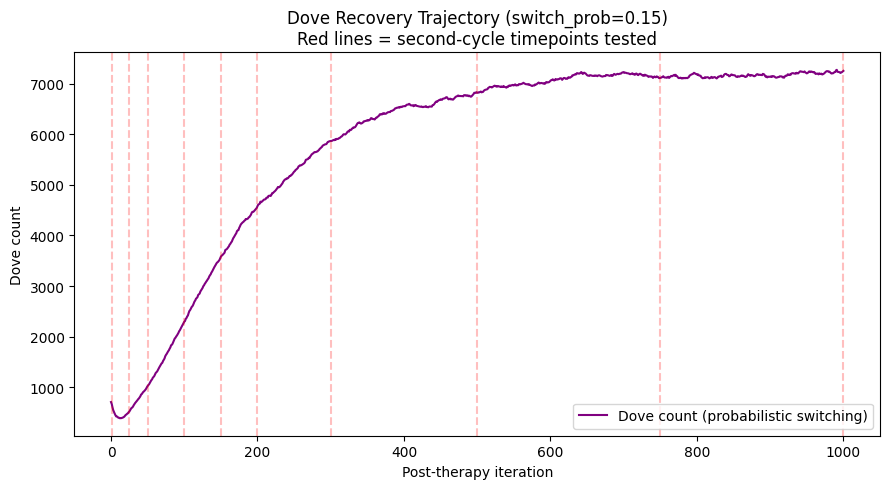

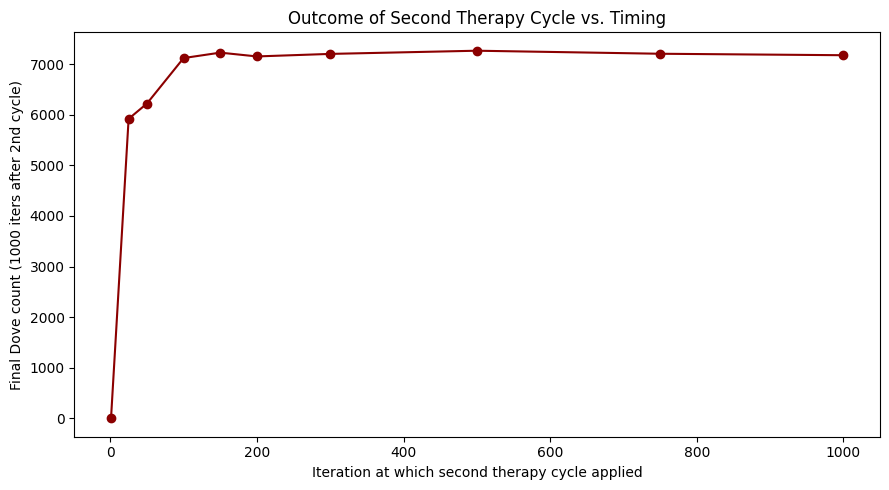

Baseline pre-therapy Doves: 7193
Switch probability per iteration: 0.15

Second-cycle timing sweep:
  t=   1  Doves at 2nd cycle=  670  -> final Doves=    0
  t=  25  Doves at 2nd cycle=  520  -> final Doves= 5918
  t=  50  Doves at 2nd cycle= 1025  -> final Doves= 6220
  t= 100  Doves at 2nd cycle= 2295  -> final Doves= 7119
  t= 150  Doves at 2nd cycle= 3580  -> final Doves= 7226
  t= 200  Doves at 2nd cycle= 4579  -> final Doves= 7151
  t= 300  Doves at 2nd cycle= 5866  -> final Doves= 7201
  t= 500  Doves at 2nd cycle= 6819  -> final Doves= 7264
  t= 750  Doves at 2nd cycle= 7114  -> final Doves= 7204
  t=1000  Doves at 2nd cycle= 7251  -> final Doves= 7175

Best (lowest final Doves): t=1 -> 0
Worst (highest final Doves): t=500 -> 7264
Spread across timing conditions: 7264 Doves (100.0% of worst-case)


In [10]:
# Evolutionary trap test timed second therapy cycle ---
#   1. Probabilistic strategy switching: a cell only adopts a higher-payoff neighbor's
#      strategy with probability `switch_prob` per iteration, rather than deterministically
#      every iteration.
#   2. A timepoint SWEEP (not just two conditions) across the recovery curve, so we can see
#      the actual shape of any timing-dependent effect rather than testing two arbitrary points.

import numpy as np
import matplotlib.pyplot as plt

switch_prob = 0.15  # probability a cell adopts a higher-payoff neighbor's strategy per iteration

def update_grid_probabilistic(grid, b, c, I_grid, switch_prob):
    """Vectorized equivalent of the original per-cell update_grid_probabilistic: computes
    payoff for the whole grid at once (via calculate_payoff_grid, from the shared functions
    cell), then applies the same probabilistic-imitation rule to every cell simultaneously."""
    grid_num = grid_to_num(grid)
    payoff = calculate_payoff_grid(grid_num, I_grid, b, c)
    directions = np.random.randint(0, 4, size=grid_num.shape)
    new_grid_num = grid_num.copy()
    shifts = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    for d, (di, dj) in enumerate(shifts):
        mask_dir = (directions == d)
        nb_grid = np.full_like(grid_num, -1)
        nb_payoff = np.full_like(payoff, -np.inf)
        src = [slice(None), slice(None)]
        dst = [slice(None), slice(None)]
        if di == -1:
            dst[0] = slice(1, None); src[0] = slice(None, -1)
        elif di == 1:
            dst[0] = slice(None, -1); src[0] = slice(1, None)
        if dj == -1:
            dst[1] = slice(1, None); src[1] = slice(None, -1)
        elif dj == 1:
            dst[1] = slice(None, -1); src[1] = slice(1, None)
        nb_grid[tuple(dst)] = grid_num[tuple(src)]
        nb_payoff[tuple(dst)] = payoff[tuple(src)]
        valid_nb = nb_grid >= 0
        # Same rule as before: strictly higher neighbor payoff AND a per-cell coin flip
        # at probability switch_prob
        coin_flip = np.random.rand(*grid_num.shape) < switch_prob
        adopt = mask_dir & valid_nb & (nb_payoff > payoff) & coin_flip
        new_grid_num = np.where(adopt, nb_grid, new_grid_num)
    return grid_to_str(new_grid_num)

def apply_therapy(g, survival_frac=0.1):
    return np.where(np.random.rand(*g.shape) < survival_frac, g, 'H')

def dove_count(g):
    return int(np.sum(g == 'D'))

# --- Step 1: re-equilibrate to a pre-therapy baseline under the SAME probabilistic rule
baseline_grid = np.random.choice(['H', 'D'], size=(n, n))
for _ in range(iterations):
    baseline_grid = update_grid_probabilistic(baseline_grid, b, c, I_grid, switch_prob)
pre_therapy_doves = dove_count(baseline_grid)

# --- Step 2: apply first therapy cycle, track Dove count at every iteration ---
first_cycle_grid = apply_therapy(baseline_grid)
trajectory = [dove_count(first_cycle_grid)]
trajectory_grids = [first_cycle_grid.copy()]
recovery_iterations = 1000
g = first_cycle_grid.copy()
for step in range(recovery_iterations):
    g = update_grid_probabilistic(g, b, c, I_grid, switch_prob)
    trajectory.append(dove_count(g))
    trajectory_grids.append(g.copy())
trajectory = np.array(trajectory)

# --- Step 3: sweep second-cycle timing across the recovery curve ---
sweep_timepoints = [1, 25, 50, 100, 150, 200, 300, 500, 750, 1000]
sweep_results = []
for t in sweep_timepoints:
    t = min(t, len(trajectory_grids) - 1)
    grid_at_t = trajectory_grids[t]
    second_cycle_grid = apply_therapy(grid_at_t)
    for _ in range(recovery_iterations):
        second_cycle_grid = update_grid_probabilistic(second_cycle_grid, b, c, I_grid, switch_prob)
    final_doves = dove_count(second_cycle_grid)
    sweep_results.append({
        'timepoint': t,
        'doves_at_second_cycle': dove_count(grid_at_t),
        'final_doves_after_second_cycle': final_doves,
    })

# --- Plot 1: recovery trajectory with sweep points marked ---
plt.figure(figsize=(9, 5))
plt.plot(trajectory, color='purple', label='Dove count (probabilistic switching)')
for r in sweep_results:
    plt.axvline(r['timepoint'], color='red', alpha=0.25, linestyle='--')
plt.xlabel('Post-therapy iteration')
plt.ylabel('Dove count')
plt.title(f'Dove Recovery Trajectory (switch_prob={switch_prob})\nRed lines = second-cycle timepoints tested')
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot 2: final outcome vs. second-cycle timing ---
timepoints_arr = [r['timepoint'] for r in sweep_results]
final_doves_arr = [r['final_doves_after_second_cycle'] for r in sweep_results]
plt.figure(figsize=(9, 5))
plt.plot(timepoints_arr, final_doves_arr, marker='o', color='darkred')
plt.xlabel('Iteration at which second therapy cycle applied')
plt.ylabel('Final Dove count (1000 iters after 2nd cycle)')
plt.title('Outcome of Second Therapy Cycle vs. Timing')
plt.tight_layout()
plt.show()

# --- Summary ---
print(f"Baseline pre-therapy Doves: {pre_therapy_doves}")
print(f"Switch probability per iteration: {switch_prob}\n")
print("Second-cycle timing sweep:")
for r in sweep_results:
    print(f"  t={r['timepoint']:4d}  Doves at 2nd cycle={r['doves_at_second_cycle']:5d}  "
          f"-> final Doves={r['final_doves_after_second_cycle']:5d}")

best = min(sweep_results, key=lambda r: r['final_doves_after_second_cycle'])
worst = max(sweep_results, key=lambda r: r['final_doves_after_second_cycle'])
spread = worst['final_doves_after_second_cycle'] - best['final_doves_after_second_cycle']
print(f"\nBest (lowest final Doves): t={best['timepoint']} -> {best['final_doves_after_second_cycle']}")
print(f"Worst (highest final Doves): t={worst['timepoint']} -> {worst['final_doves_after_second_cycle']}")
if worst['final_doves_after_second_cycle'] > 0:
    print(f"Spread across timing conditions: {spread} Doves ({100*spread/worst['final_doves_after_second_cycle']:.1f}% of worst-case)")
else:
    print(f"Spread across timing conditions: {spread} Doves (all timepoints resulted in extinction)")

Robustness check: 5 independent replicates per timepoint

   t |  mean final Doves |    min |    max | extinctions
------------------------------------------------------------
   1 |            2374.8 |      0 |   3518 | 1/5        
   3 |            1550.0 |      0 |   3499 | 1/5        
   5 |            2071.8 |      0 |   4584 | 1/5        
   8 |            2465.4 |      0 |   5052 | 1/5        
  10 |            4696.8 |   3041 |   5731 | 0/5        
  13 |            2591.2 |      0 |   3831 | 1/5        
  16 |            4497.4 |      0 |   6959 | 1/5        
  20 |            4456.6 |   2058 |   5953 | 0/5        
  25 |            4384.4 |   2481 |   6400 | 0/5        


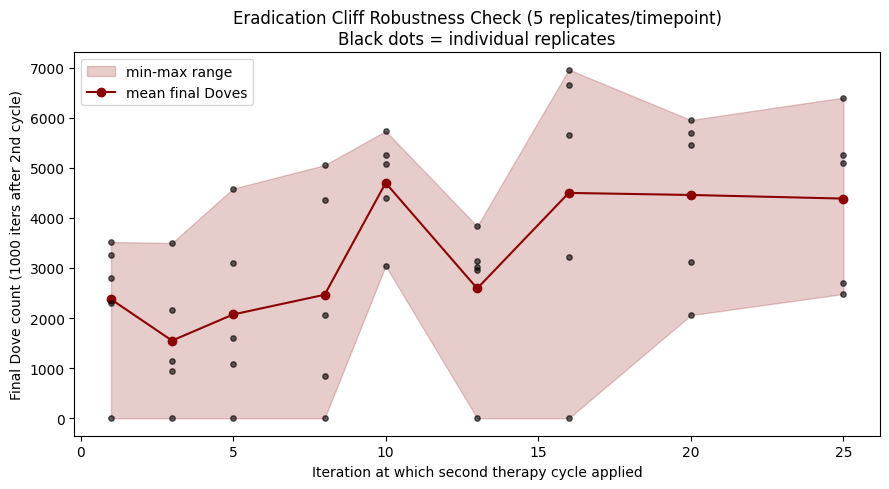


Consistent extinction (all 5 replicates) at: []
Partial/inconsistent extinction at: [1, 3, 5, 8, 13, 16]
No extinction at: [10, 20, 25]


In [11]:
# Robustness Check: locating the eradication cliff, with replicates ---
# fine-grained timepoints (1, 3, 5, 8, 10, 13, 16, 20, 25) with N_REPLICATES independent
# random seeds per timepoint, reporting mean/min/max final Dove count at each.


import numpy as np
import matplotlib.pyplot as plt

N_REPLICATES = 5
fine_timepoints = [1, 3, 5, 8, 10, 13, 16, 20, 25]
recovery_iterations_check = 1000  # match v2 for direct comparability

robustness_results = {t: [] for t in fine_timepoints}

for rep in range(N_REPLICATES):
    # Fresh independent baseline + first cycle for each replicate (different random seed
    # implicitly, since numpy's global RNG advances). This tests whether the cliff is a
    # property of the dynamics, not one lucky grid configuration.
    rep_baseline = np.random.choice(['H', 'D'], size=(n, n))
    for _ in range(iterations):
        rep_baseline = update_grid_probabilistic(rep_baseline, b, c, I_grid, switch_prob)

    rep_first_cycle = apply_therapy(rep_baseline)
    rep_trajectory_grids = [rep_first_cycle.copy()]
    g = rep_first_cycle.copy()
    max_t = max(fine_timepoints)
    for step in range(max_t):
        g = update_grid_probabilistic(g, b, c, I_grid, switch_prob)
        rep_trajectory_grids.append(g.copy())

    for t in fine_timepoints:
        grid_at_t = rep_trajectory_grids[t]
        doves_at_t = dove_count(grid_at_t)
        second_cycle_grid = apply_therapy(grid_at_t)
        for _ in range(recovery_iterations_check):
            second_cycle_grid = update_grid_probabilistic(second_cycle_grid, b, c, I_grid, switch_prob)
        final_doves = dove_count(second_cycle_grid)
        robustness_results[t].append({
            'replicate': rep,
            'doves_at_second_cycle': doves_at_t,
            'final_doves': final_doves,
        })

# --- Summarize: mean / min / max / extinction rate per timepoint ---
print(f"Robustness check: {N_REPLICATES} independent replicates per timepoint\n")
print(f"{'t':>4} | {'mean final Doves':>17} | {'min':>6} | {'max':>6} | {'extinctions':>11}")
print("-" * 60)
summary = []
for t in fine_timepoints:
    finals = [r['final_doves'] for r in robustness_results[t]]
    n_extinct = sum(1 for f in finals if f == 0)
    mean_final = np.mean(finals)
    summary.append({'t': t, 'mean': mean_final, 'min': min(finals), 'max': max(finals),
                     'n_extinct': n_extinct, 'all_finals': finals})
    print(f"{t:>4} | {mean_final:>17.1f} | {min(finals):>6} | {max(finals):>6} | "
          f"{n_extinct}/{N_REPLICATES:<9}")

# --- Plot: mean final Doves vs timepoint, with min-max range and individual replicate dots ---
plt.figure(figsize=(9, 5))
means = [s['mean'] for s in summary]
mins = [s['min'] for s in summary]
maxs = [s['max'] for s in summary]
plt.fill_between(fine_timepoints, mins, maxs, alpha=0.2, color='darkred', label='min-max range')
plt.plot(fine_timepoints, means, marker='o', color='darkred', label='mean final Doves')
for s in summary:
    plt.scatter([s['t']] * len(s['all_finals']), s['all_finals'], color='black', s=15, alpha=0.6, zorder=5)
plt.xlabel('Iteration at which second therapy cycle applied')
plt.ylabel(f'Final Dove count ({recovery_iterations_check} iters after 2nd cycle)')
plt.title(f'Eradication Cliff Robustness Check ({N_REPLICATES} replicates/timepoint)\nBlack dots = individual replicates')
plt.legend()
plt.tight_layout()
plt.show()

# --- Interpretation flag ---
extinction_timepoints = [s['t'] for s in summary if s['n_extinct'] == N_REPLICATES]
partial_timepoints = [s['t'] for s in summary if 0 < s['n_extinct'] < N_REPLICATES]
no_extinction_timepoints = [s['t'] for s in summary if s['n_extinct'] == 0]

print(f"\nConsistent extinction (all {N_REPLICATES} replicates) at: {extinction_timepoints}")
print(f"Partial/inconsistent extinction at: {partial_timepoints}")
print(f"No extinction at: {no_extinction_timepoints}")


Total runs: 45
Population size at 2nd cycle, range: 300 to 672
Extinctions: 6 / 45

Individual extinct runs (timepoint, population size at 2nd cycle):
  t=   1, doves_at_second_cycle=672
  t=   3, doves_at_second_cycle=522
  t=   5, doves_at_second_cycle=441
  t=   8, doves_at_second_cycle=425
  t=  13, doves_at_second_cycle=410
  t=  16, doves_at_second_cycle=304

     Pop. size bin |  n runs | extinctions | extinction rate
------------------------------------------------------------
       0-1000     |      45 |           6 |          13.3%

Correlation (population size at intervention vs. extinction): r = -0.052


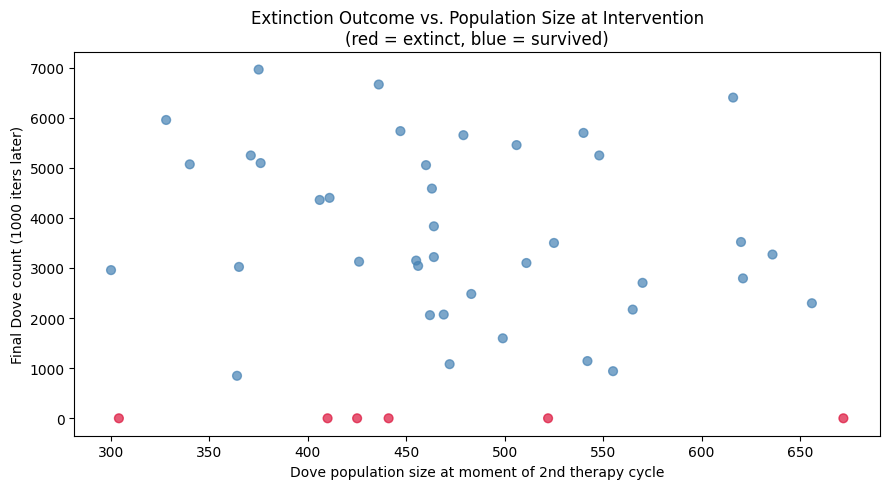

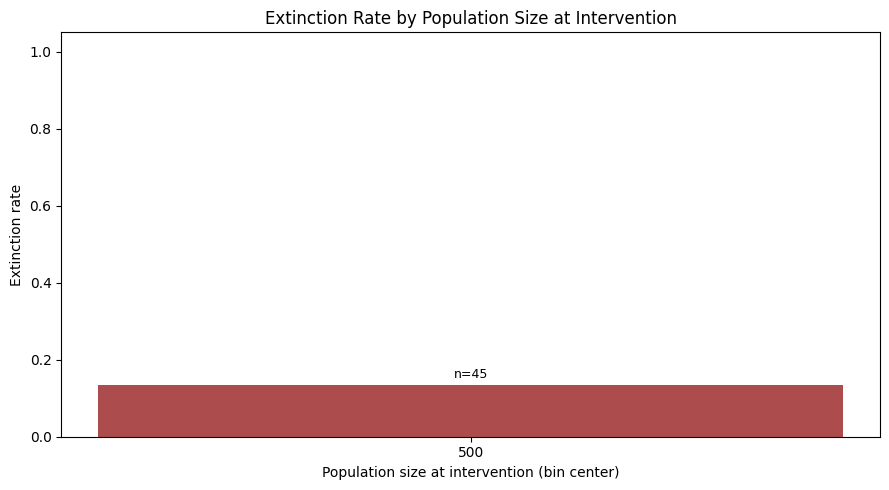

In [12]:
# Does population size at intervention predict extinction? ---


import numpy as np
import matplotlib.pyplot as plt

# Flatten all 45 runs into (population size at 2nd cycle, final outcome) pairs
all_runs = []
for t, runs in robustness_results.items():
    for r in runs:
        all_runs.append({
            'timepoint': t,
            'doves_at_second_cycle': r['doves_at_second_cycle'],
            'final_doves': r['final_doves'],
            'went_extinct': r['final_doves'] == 0,
        })

pop_sizes = np.array([r['doves_at_second_cycle'] for r in all_runs])
final_doves = np.array([r['final_doves'] for r in all_runs])
extinct_mask = final_doves == 0

print(f"Total runs: {len(all_runs)}")
print(f"Population size at 2nd cycle, range: {pop_sizes.min()} to {pop_sizes.max()}")
print(f"Extinctions: {extinct_mask.sum()} / {len(all_runs)}\n")


print("Individual extinct runs (timepoint, population size at 2nd cycle):")
for r in all_runs:
    if r['went_extinct']:
        print(f"  t={r['timepoint']:4d}, doves_at_second_cycle={r['doves_at_second_cycle']}")
print()

# Bin by population size at intervention (not by timepoint) and report extinction rate per bin
bin_edges = [0, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000]
print(f"{'Pop. size bin':>18} | {'n runs':>7} | {'extinctions':>11} | {'extinction rate':>15}")
print("-" * 60)
bin_centers, bin_rates, bin_counts = [], [], []
for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
    in_bin = (pop_sizes >= lo) & (pop_sizes < hi)
    n_in_bin = in_bin.sum()
    if n_in_bin > 0:
        n_extinct_bin = extinct_mask[in_bin].sum()
        rate = n_extinct_bin / n_in_bin
        bin_centers.append((lo + hi) / 2)
        bin_rates.append(rate)
        bin_counts.append(n_in_bin)
        print(f"{lo:>8}-{hi:<8} | {n_in_bin:>7} | {n_extinct_bin:>11} | {rate:>14.1%}")

# correlation between population size and extinction (binary outcome)
if len(set(extinct_mask)) > 1:  # need variation in both variables
    corr = np.corrcoef(pop_sizes, extinct_mask.astype(int))[0, 1]
    print(f"\nCorrelation (population size at intervention vs. extinction): r = {corr:.3f}")
else:
    corr = None
    print("\nInsufficient variation in outcomes to compute correlation.")

# --- Plot: extinction outcome vs population size at intervention, all 45 runs ---
plt.figure(figsize=(9, 5))
colors = ['crimson' if e else 'steelblue' for e in extinct_mask]
plt.scatter(pop_sizes, final_doves, c=colors, alpha=0.7, s=40)
plt.xlabel('Dove population size at moment of 2nd therapy cycle')
plt.ylabel('Final Dove count (1000 iters later)')
plt.title('Extinction Outcome vs. Population Size at Intervention\n(red = extinct, blue = survived)')
plt.tight_layout()
plt.show()

# --- Plot: extinction rate per population-size bin ---
plt.figure(figsize=(9, 5))
plt.bar(range(len(bin_rates)), bin_rates, tick_label=[f"{int(c)}" for c in bin_centers], color='darkred', alpha=0.7)
for i, n in enumerate(bin_counts):
    plt.text(i, bin_rates[i] + 0.02, f"n={n}", ha='center', fontsize=9)
plt.xlabel('Population size at intervention (bin center)')
plt.ylabel('Extinction rate')
plt.title('Extinction Rate by Population Size at Intervention')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()
